### Building a Basic Chatbot with Langgraph(Graph Api)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class state(TypedDict):
    messages:Annotated[list, add_messages]

graph_builder = StateGraph(state)

In [3]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [4]:
# node functionality
def chatbot(state:state):
    return {'messages':[llm.invoke(state["messages"])]}

In [5]:
graph_builder = StateGraph(state)

#addding node to the graph
graph_builder.add_node("llmchatbot", chatbot)

#adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot", END)

## compile the graph
graph = graph_builder.compile()

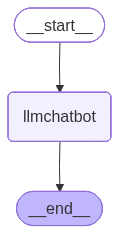

In [6]:
#visualization graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [7]:
response = graph.invoke({"messages":"hi"})

In [8]:
for event in graph.stream({"messages":"hi, how are you today?"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello, I'm doing well, thanks for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm here and ready to help you with any questions or topics you'd like to discuss. How about you? How's your day going so far?


In [77]:
# To install: pip install tavily-python
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(max_result=2)
tavily_search.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial',
   'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It?',
   'content': "# LangGraph Tutorial: What Is LangGraph and How to Use It? LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner. Imagine you're building a complex, multi-agent large language model (LLM) application. It's exciting, but it comes with challenges: managing the state of various agents, coordinating their interactions, and handling errors effectively. LangGraph provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured manner. The core concepts of LangGraph include: graph structure, state management, and coordination. In LangGraph, each node represents

In [78]:
## custom tool function
from langchain_core.tools import tool

@tool
def multipl(a: int, b: int) -> int:
    """Multiply two integers."""
    return a * b


In [80]:
tools = [tavily_search, multipl]

In [81]:
llm_with_tools = llm.bind_tools(tools)

In [82]:
for t in tools:
    print(t)

api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None)
name='multipl' description='Multiply two integers.' args_schema=<class 'langchain_core.utils.pydantic.multipl'> func=<function multipl at 0x000002A973644A90>


In [83]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002A96E9D7E00>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002A96EC34980>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool del

In [84]:
for t in tools:
    print(t.name)

tavily_search
multipl


In [88]:
#stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## node defination
def tool_calling_llm(state:state):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Graph
builder=StateGraph(state)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    #"if the latest message (result) from assisant is tool calling -> tool_conditons routes to tools"
    #"if the latest message (result) from assisant is not tool calling -> conditons routes to END"
    tools_condition
)

builder.add_edge("tools",END)

# compile the graph
graph = builder.compile()

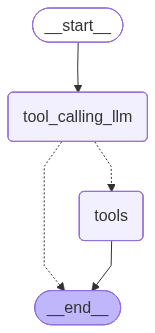

In [89]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [90]:
response = graph.invoke({"messages":"what is the recent ai news"})
response

{'messages': [HumanMessage(content='what is the recent ai news', additional_kwargs={}, response_metadata={}, id='c3cba098-1948-4da5-8764-82bd4dcfa21c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'scyhs0t8x', 'function': {'arguments': '{"query":"recent AI news","search_depth":"advanced","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 1741, 'total_tokens': 1779, 'completion_time': 0.091051231, 'completion_tokens_details': None, 'prompt_time': 0.089882821, 'prompt_tokens_details': None, 'queue_time': 0.052845169, 'total_time': 0.180934052}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee992-69c3-7301-93cd-1245df0f28ef-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent AI news', 'searc

In [58]:
response = graph.invoke({"messages":"what is the 2 * 3"})
response

{'messages': [HumanMessage(content='what is the 2 * 3', additional_kwargs={}, response_metadata={}, id='633fe587-33a5-4097-80f2-8f50eb0806da'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'c554dvfyk', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multipl'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1743, 'total_tokens': 1763, 'completion_time': 0.060267906, 'completion_tokens_details': None, 'prompt_time': 0.090863479, 'prompt_tokens_details': None, 'queue_time': 0.056558441, 'total_time': 0.151131385}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee980-dd05-7e03-b2af-a14f1093b76f-0', tool_calls=[{'name': 'multipl', 'args': {'a': 2, 'b': 3}, 'id': 'c554dvfyk', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1743, 'output

In [59]:
response = graph.invoke({"messages":"what is the 10 + 3"})
response

{'messages': [HumanMessage(content='what is the 10 + 3', additional_kwargs={}, response_metadata={}, id='ca662531-9728-4246-b89e-c6e63762a049'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'yyhy338qn', 'function': {'arguments': '{"a":10,"b":3}', 'name': 'multipl'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1743, 'total_tokens': 1763, 'completion_time': 0.048240375, 'completion_tokens_details': None, 'prompt_time': 0.085755, 'prompt_tokens_details': None, 'queue_time': 0.162177779, 'total_time': 0.133995375}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee981-2b5e-7041-8dff-4676705c3129-0', tool_calls=[{'name': 'multipl', 'args': {'a': 10, 'b': 3}, 'id': 'yyhy338qn', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1743, 'output

In [76]:
response = graph.invoke({"messages":"what is the current ai development"})
response

{'messages': [HumanMessage(content='what is the current ai development', additional_kwargs={}, response_metadata={}, id='0f74c6d6-88a0-4986-a174-5ad00a324e5c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '6djwgt9vd', 'function': {'arguments': '{"query":"current AI development","search_depth":"advanced","topic":"general"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 1741, 'total_tokens': 1772, 'completion_time': 0.084074185, 'completion_tokens_details': None, 'prompt_time': 0.104491845, 'prompt_tokens_details': None, 'queue_time': 0.052341615, 'total_time': 0.18856603}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee98a-b152-7ae2-8028-e0cc0a7267ee-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'current AI development',

In [61]:
response = graph.invoke({"messages":"give me recent ai news and 2 * 3"})
response

{'messages': [HumanMessage(content='give me recent ai news and 2 * 3', additional_kwargs={}, response_metadata={}, id='5e5a65e2-dab2-4ba0-8185-69f4d48090a7'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'dmerghnfw', 'function': {'arguments': '{"query":"recent AI news","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}, {'id': 'ygctvhajz', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multipl'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 50, 'prompt_tokens': 1746, 'total_tokens': 1796, 'completion_time': 0.123426488, 'completion_tokens_details': None, 'prompt_time': 0.094821888, 'prompt_tokens_details': None, 'queue_time': 0.162080612, 'total_time': 0.218248376}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee984-09a6-7f72-b287-facc561f6529-

### Adding Memory to Agentic Graph

In [91]:
#stategraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## node defination
def tool_calling_llm(state:state):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Graph
builder=StateGraph(state)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    #"if the latest message (result) from assisant is tool calling -> tool_conditons routes to tools"
    #"if the latest message (result) from assisant is not tool calling -> conditons routes to END"
    tools_condition
)

builder.add_edge("tools",END)

# compile the graph
graph = builder.compile(checkpointer=memory)

In [93]:
config = {"configurable":{"thread_id":"1"}}

response = graph.invoke({"messages":"hi my name is devendra chavan"}, config=config)
response

{'messages': [HumanMessage(content='hi my name is devendra chavan', additional_kwargs={}, response_metadata={}, id='58e21b39-9f22-4aa8-97f9-7558571ec28f'),
  AIMessage(content="Hello Devendra Chavan, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 1743, 'total_tokens': 1772, 'completion_time': 0.088886375, 'completion_tokens_details': None, 'prompt_time': 0.094251323, 'prompt_tokens_details': None, 'queue_time': 0.057475377, 'total_time': 0.183137698}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee9bc-ac1e-7253-9e09-f934fbb0d768-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1743, 'output_tokens': 29, 'total_tokens': 1772})]}

In [94]:
graph.invoke({"messages":"what is my name"}, config=config)

{'messages': [HumanMessage(content='hi my name is devendra chavan', additional_kwargs={}, response_metadata={}, id='58e21b39-9f22-4aa8-97f9-7558571ec28f'),
  AIMessage(content="Hello Devendra Chavan, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 1743, 'total_tokens': 1772, 'completion_time': 0.088886375, 'completion_tokens_details': None, 'prompt_time': 0.094251323, 'prompt_tokens_details': None, 'queue_time': 0.057475377, 'total_time': 0.183137698}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee9bc-ac1e-7253-9e09-f934fbb0d768-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1743, 'output_tokens': 29, 'total_tokens': 1772}),
  HumanMessage(content='what is my name', additi